Accuracy: 0.5048
[[2732 2236]
 [2716 2316]]
              precision    recall  f1-score   support

       False       0.50      0.55      0.52      4968
        True       0.51      0.46      0.48      5032

    accuracy                           0.50     10000
   macro avg       0.51      0.51      0.50     10000
weighted avg       0.51      0.50      0.50     10000



C:\Users\user\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


['lr.joblib']

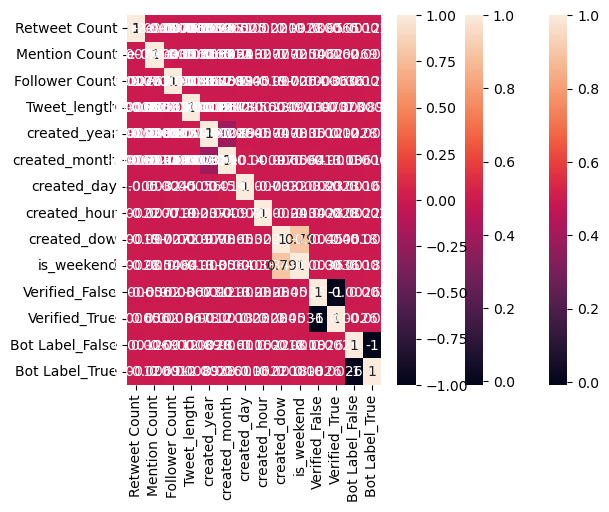

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("C:/Users/user/Downloads/archive/bot_detection_data.csv")

df

df.shape

df.columns

df.isnull().sum()

df.dtypes

df.head()

df.info

df.describe





df=df.drop("Hashtags",axis=1)
df

df.isnull().sum()

df.corr(numeric_only=True)["Bot Label"]


sns.heatmap(df.corr(numeric_only=True),annot=True)



df['Bot Label'] = df['Bot Label'].astype(bool)

df.head()

df['Tweet_length'] = df['Tweet'].apply(len)

df["Year"]=pd.to_datetime(df["Created At"]).dt.year

df["Month"]=pd.to_datetime(df["Created At"]).dt.month

df['Created At'] = pd.to_datetime(df['Created At'], errors='coerce')

df = df.astype({
    'Year': 'int64',
    'Month': 'int64'
})


df.head()

df.drop(['User ID','Username','Tweet','Location','Month'],axis=1,inplace=True)
df.head()

df.drop('Year',axis=1,inplace=True)

sns.heatmap(df.corr(numeric_only=True),annot=True)

df['created_year']  = df['Created At'].dt.year
df['created_month'] = df['Created At'].dt.month
df['created_day']   = df['Created At'].dt.day
df['created_hour']  = df['Created At'].dt.hour
df['created_dow']   = df['Created At'].dt.dayofweek
df['is_weekend'] = df['created_dow'].isin([5, 6]).astype(int)

df.drop("Created At",inplace=True,axis=1)

df.head()

df.dtypes

df_num=df.select_dtypes(include=["int","float"])


df_num.head()

df_char=df.select_dtypes(exclude=["int","float"])

df_char.head()

df.dtypes

from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(handle_unknown='ignore',sparse_output=False)
x_ohe = ohe.fit_transform(df_char)
df_char = pd.DataFrame(
    x_ohe,
    columns=ohe.get_feature_names_out(df_char.columns),
    index=df_char.index
)

from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_num=scaler.fit_transform(df_num)
df_num= pd.DataFrame(
    x_num,
    columns=df_num.columns,
    index=df_num.index
)

df_char

df_num

after_df = pd.concat([df_num,df_char],axis=1)

after_df.head()


sns.heatmap(after_df.corr(numeric_only=True),annot=True)

after_df.isnull().sum().sum()

y = df['Bot Label']



after_df=after_df.drop(columns=['Bot Label_False','Bot Label_True'])

after_df

x = df.drop(columns=['Bot Label'])

from sklearn.model_selection import train_test_split


x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(x_train,y_train)


predictions = lr.predict(x_test)

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Accuracy
print("Accuracy:", accuracy_score(y_test, predictions))

# Confusion matrix
print(confusion_matrix(y_test, predictions))

# Detailed report (precision, recall, F1)
print(classification_report(y_test, predictions))

import joblib
joblib.dump(lr, "lr.joblib")

